In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Src.data import load_csv_df
from Src.plotting import set_plotting_style

In [31]:
# Already prepared accent pallette applying using function from mine Src module (plotting)
set_plotting_style()

In [32]:
DF_PATH = "../Data/Raw/raw-data.csv"

# Safely loading dataframe using function from mine Src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\Data\Raw\raw-data.csv
Dataframe has: 8950 rows / 18 columns
Dataframe size: 0.861MB


In [33]:
df_dtypes = df.dtypes.to_frame("Dtype").reset_index(names="Column")
display(df_dtypes)

,Column,Dtype
0,CUST_ID,str
1,BALANCE,float64
2,BALANCE_FREQUENCY,float64
3,PURCHASES,float64
4,ONEOFF_PURCHASES,float64
5,INSTALLMENTS_PURCHASES,float64
6,CASH_ADVANCE,float64
7,PURCHASES_FREQUENCY,float64
8,ONEOFF_PURCHASES_FREQUENCY,float64
9,PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [34]:
CATEGORIAL_COL = df.select_dtypes(include=["object", "string", "category"]).columns
NUMERIC_COL = df.select_dtypes(exclude=["object", "string", "category"]).columns

print(f"Dataframe contains:")
print(f"- {len(CATEGORIAL_COL)} categorical columns")
print(f"- {len(NUMERIC_COL)} numeric columns")
# Dataframe has 17 numeric columns and only 1 categorial.

Dataframe contains:
- 1 categorical columns
- 17 numeric columns


In [35]:
display(df.head(3))
display(df.tail(3))

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8947,C19188,23.398673,0.833333,144.40,0.00,144.4,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.0,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [36]:
cust_id_values = df["CUST_ID"].unique()
print(f"CustomerID values count: {len(cust_id_values)} / {df.shape[0]} (Whole df)")

# CUST_ID has exact same unique value amount (8950) as whole dataframe rows
# so it no use
df = df.drop(columns=["CUST_ID"])
print(f"Dataframe has: {df.shape[0]} rows / {df.shape[1]} columns")

CustomerID values count: 8950 / 8950 (Whole df)
Dataframe has: 8950 rows / 17 columns


In [37]:
MISSING = df.isna().sum()
print(f"Dataframe has: {MISSING} missing values")
# Dataframe has 1 missing in CREDIT_LIMIT and 313 in MINIMUM_PAYMENTS

Dataframe has: BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64 missing values


In [39]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [ ]:
DUPLICATES = df.duplicated().sum()
print(f"Dataframe has: {DUPLICATES} duplicated values")
# Dataframe doesn't have any duplicates

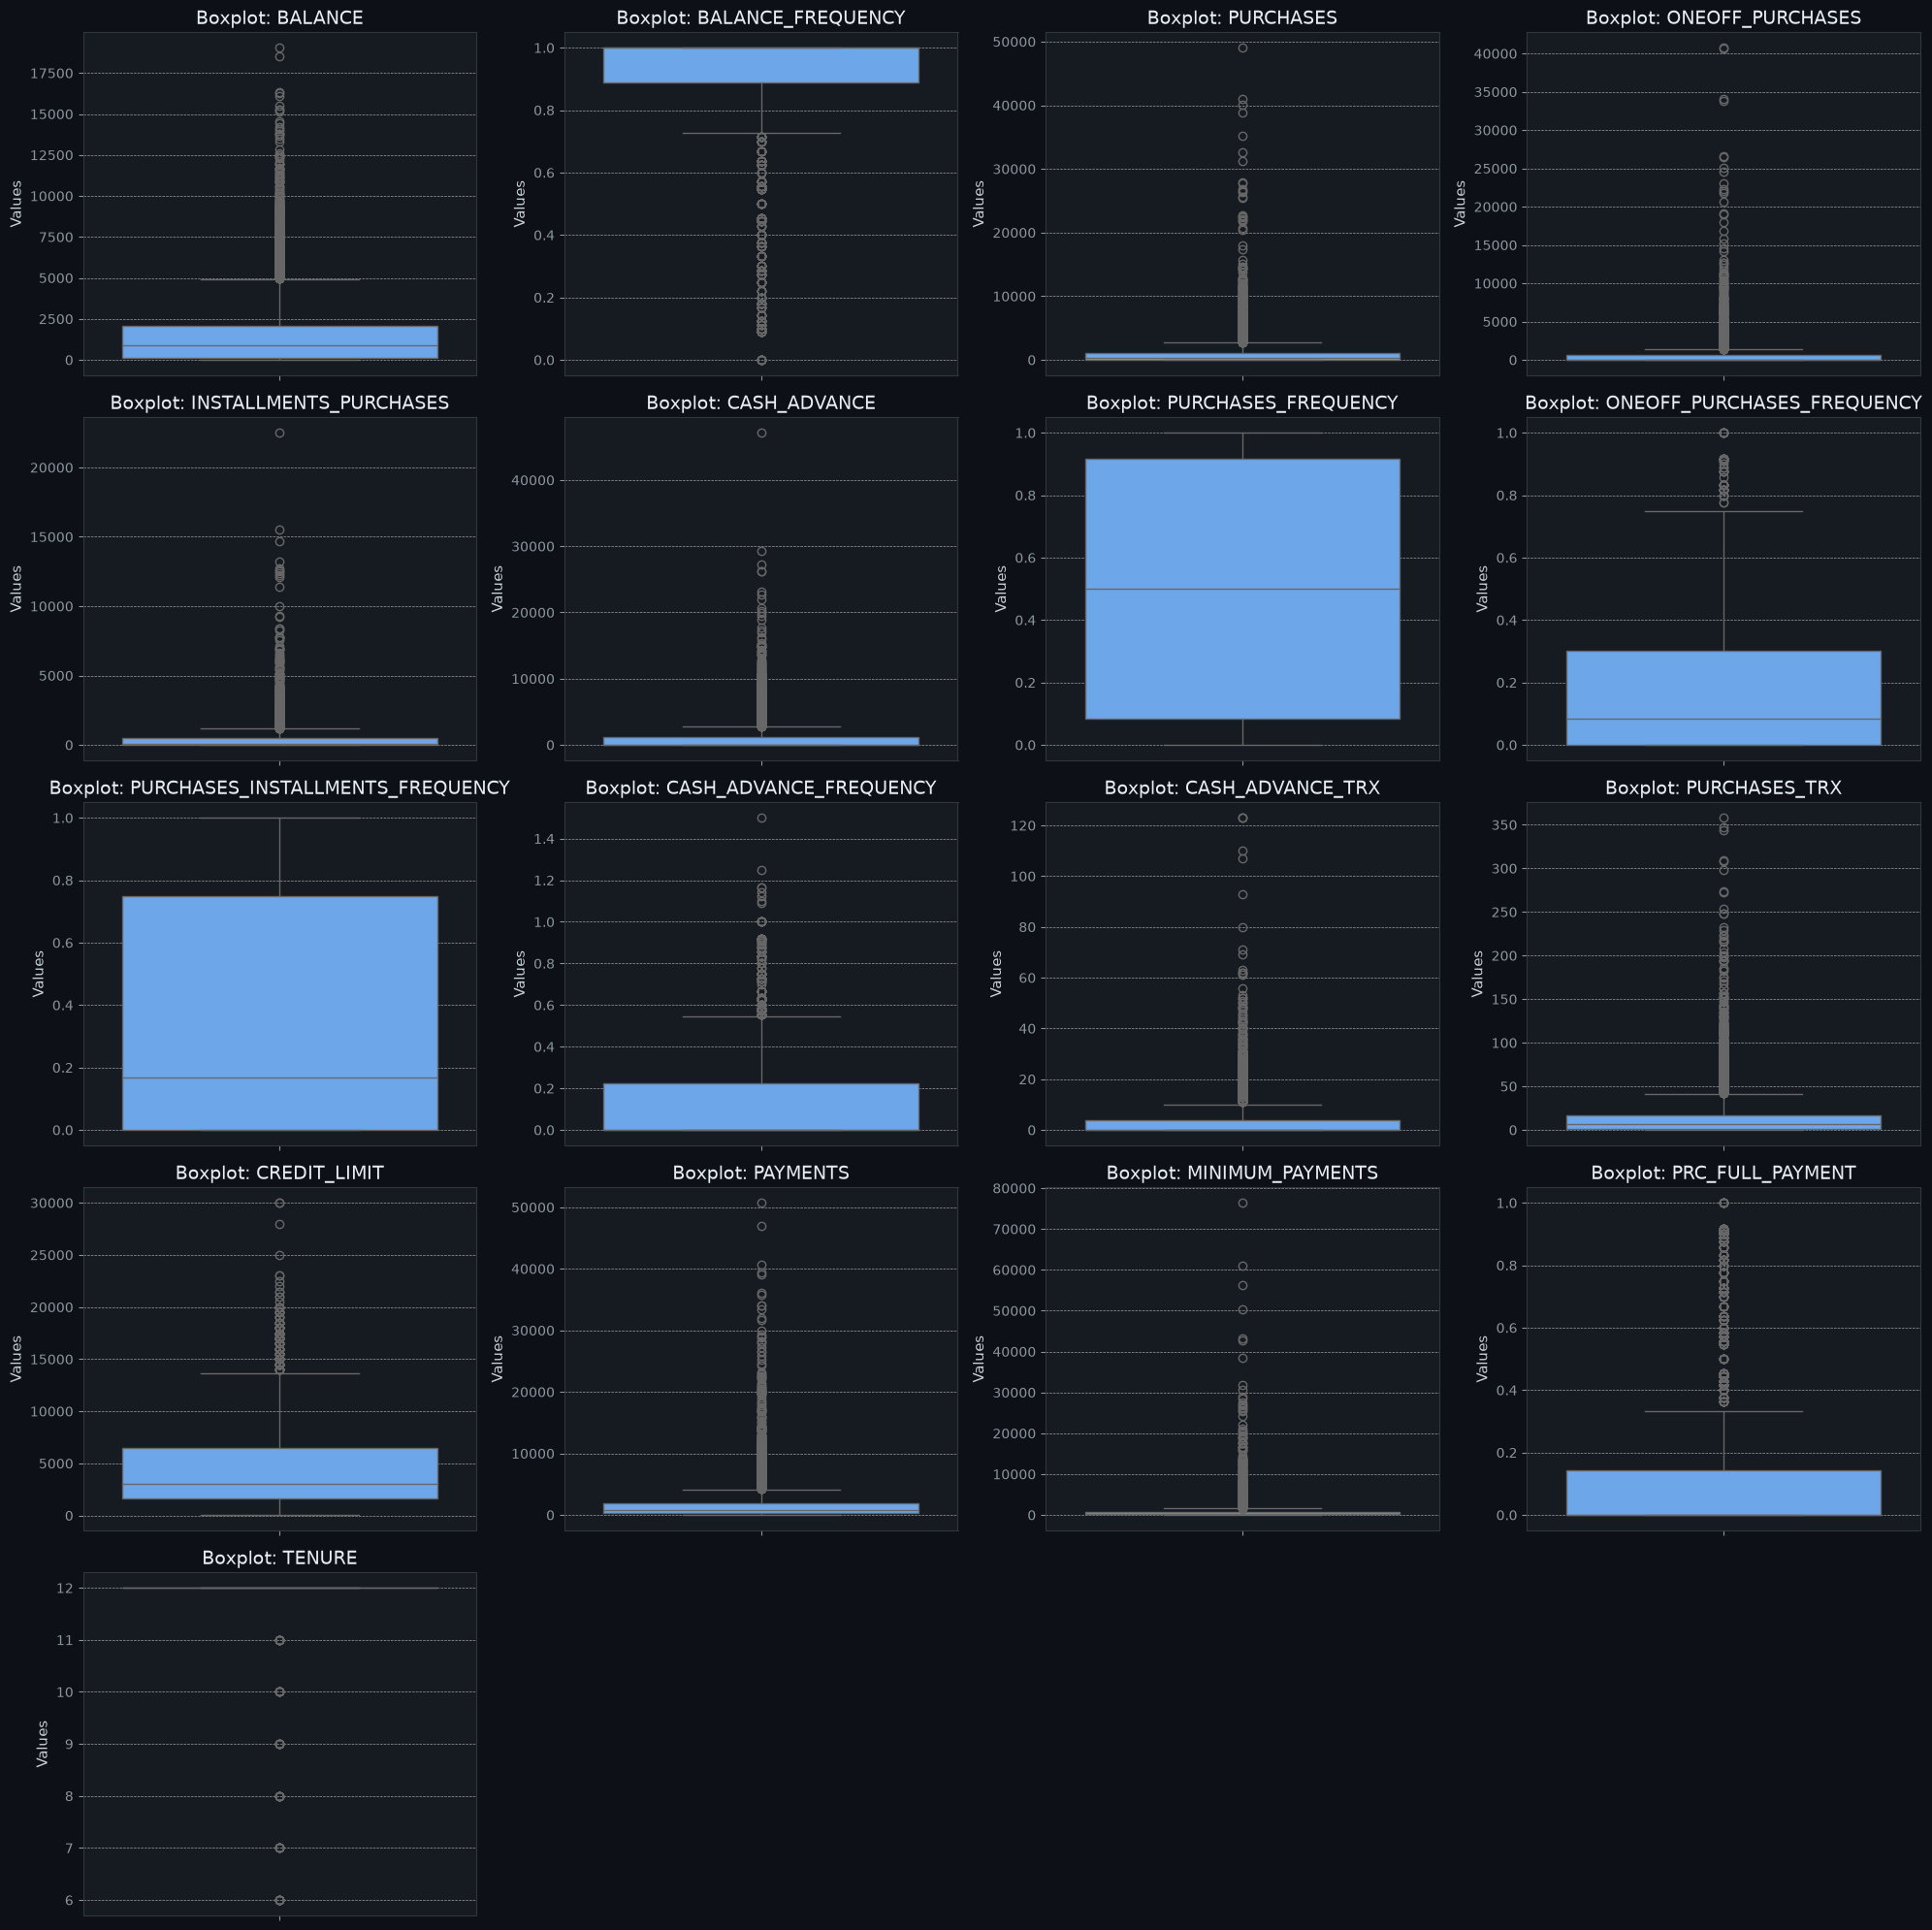

'\nAll numeric columns have outliers and must be log\nexcept TENURE which is categorial (6-12 values) and stays the same\n'

In [47]:
n_cols = 4
n_rows = (len(NUMERIC_COL) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COL):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel("Values")

for i in range(len(NUMERIC_COL), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""
All numeric columns have outliers and must be log
except TENURE which is categorial (6-12 values) and stays the same
"""

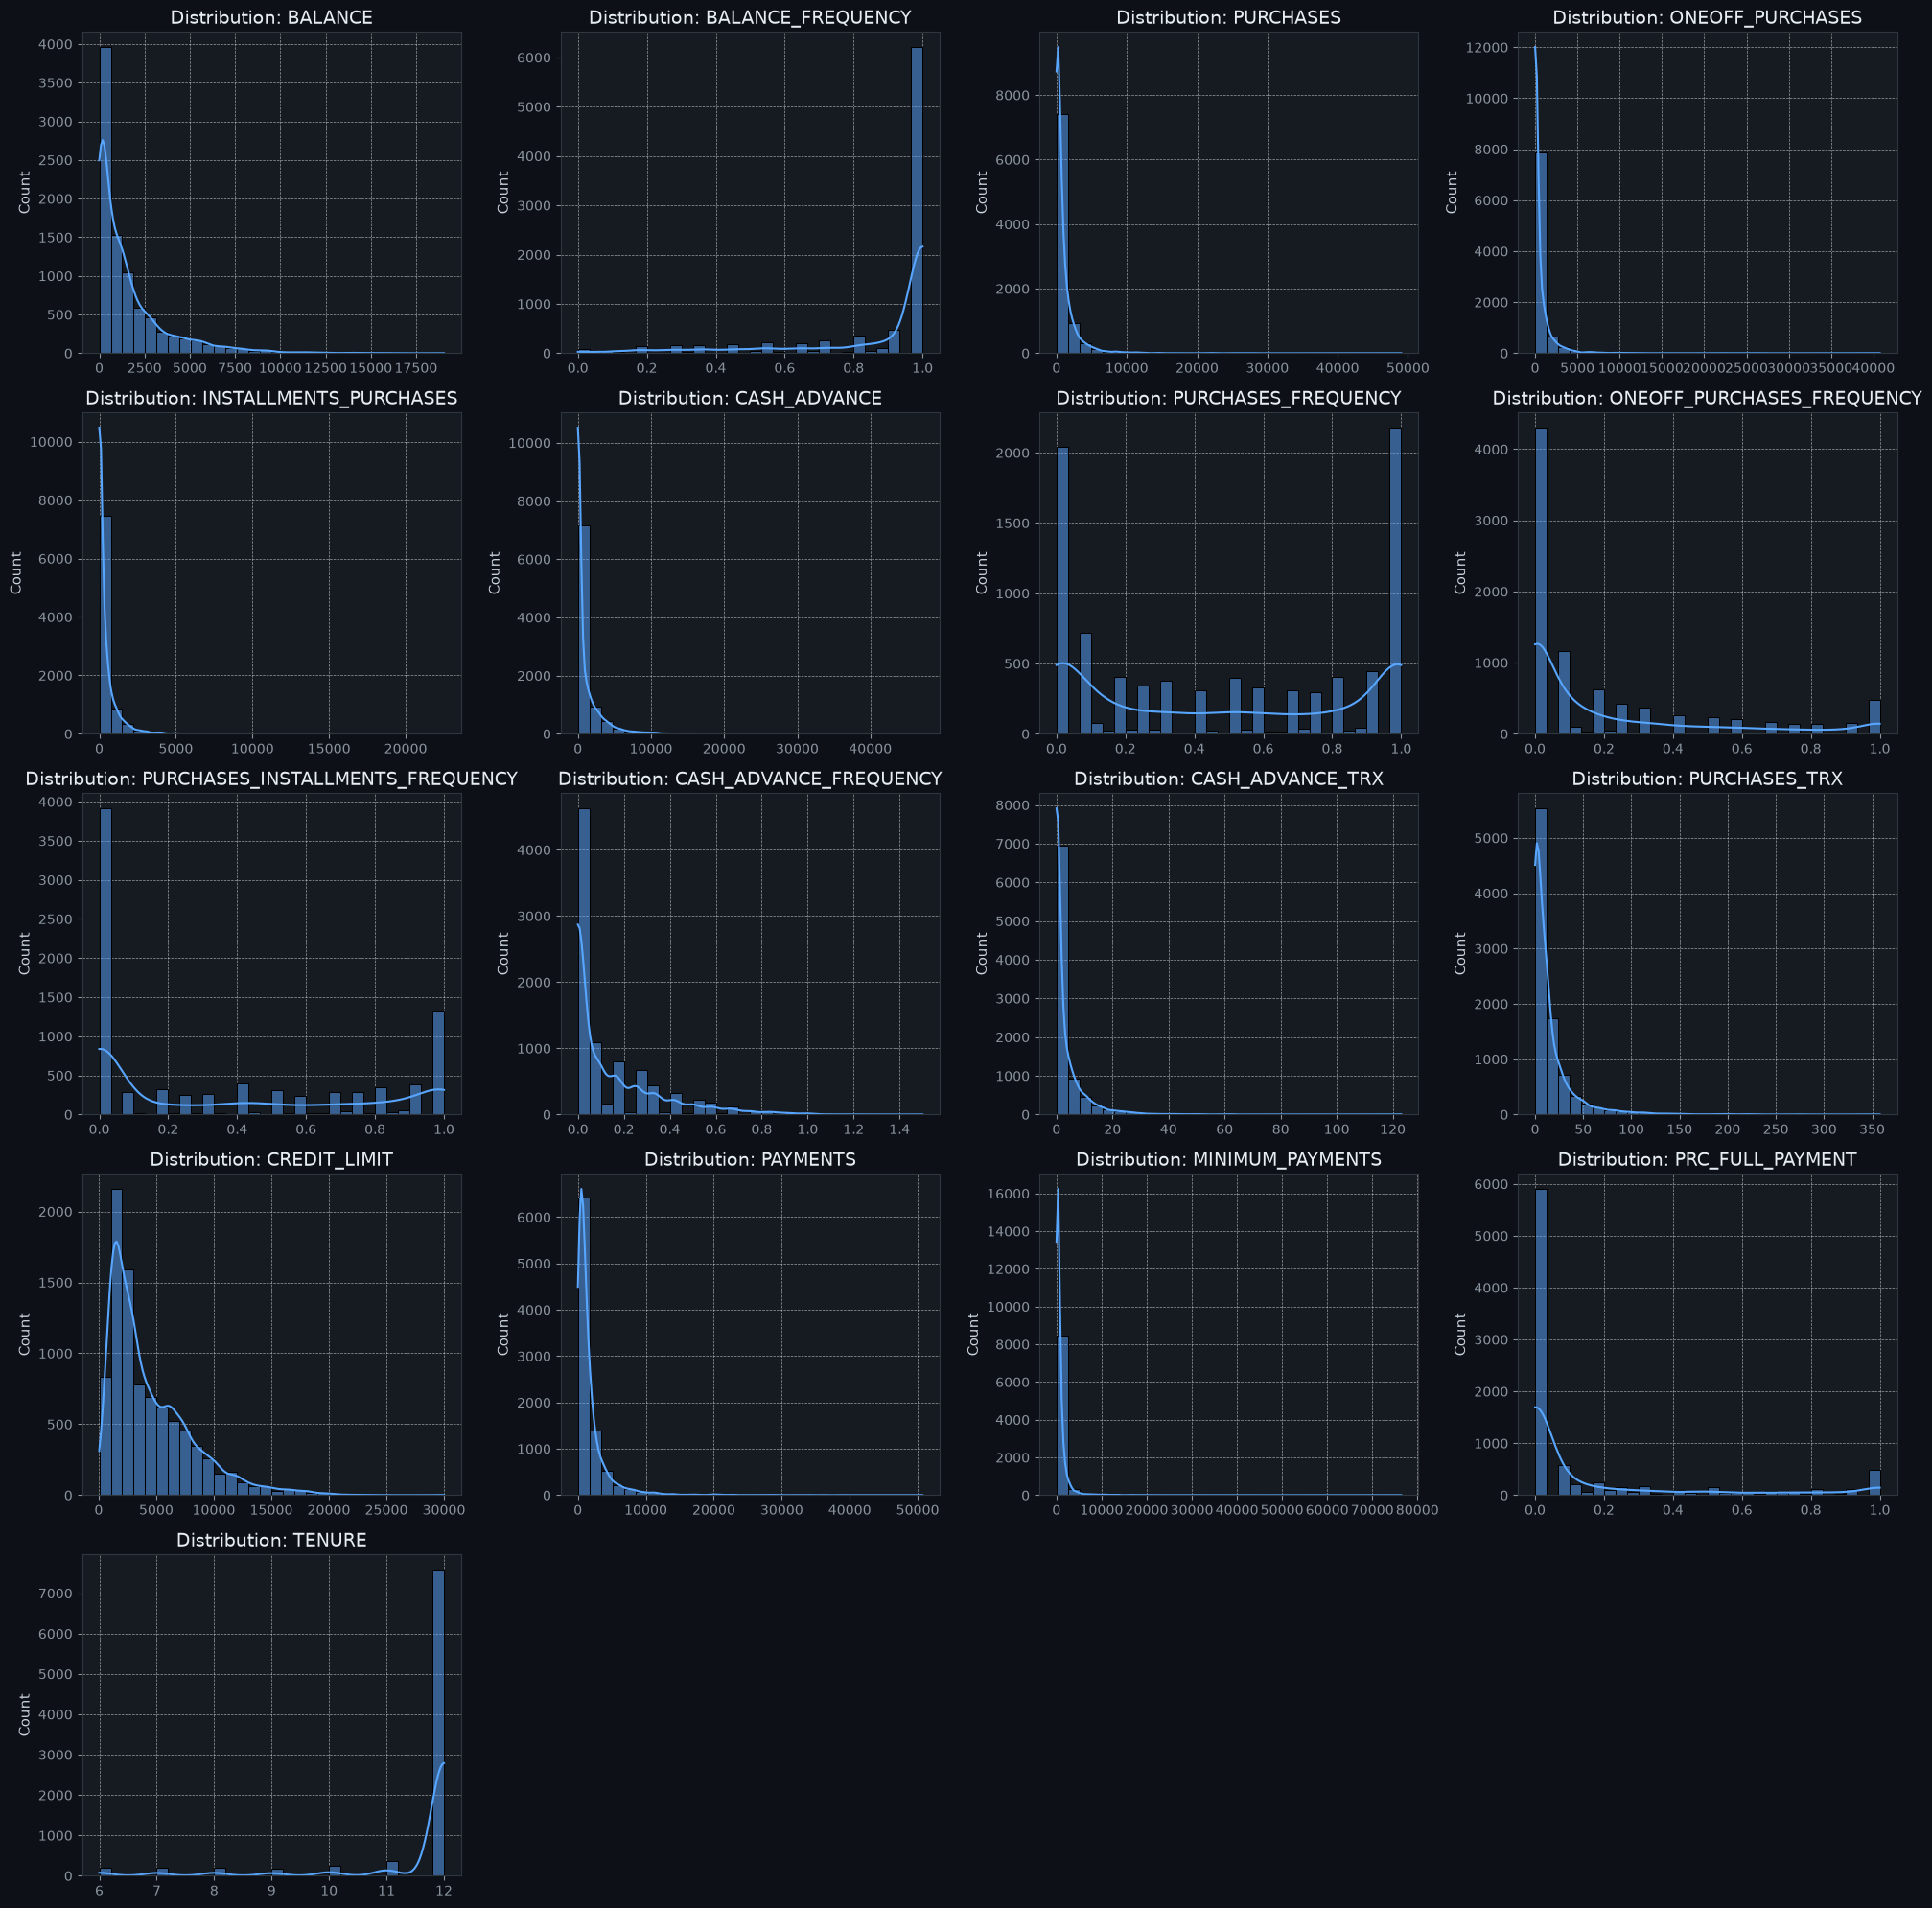

In [49]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COL):
    if col in df.columns:
        sns.histplot(
            df[col],
            kde=True,
            ax=axes[i],
            bins=30
        )
        axes[i].set_title(f"Distribution: {col}")
        axes[i].set_xlabel("")

for i in range(len(NUMERIC_COL), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""
Yes, hypothesis confirmed. All money features have rightward slope and must be log.
Otherwise, _FREQUENCY and PRC_FULL_PAYMENT U-type hist and will be only scaled
in the same way as TENURE feature.
"""

In [41]:
df_stats = df.describe().T[["mean", "min", "max", "50%", "75%"]]
display(df_stats)

,mean,min,max,50%,75%
BALANCE,1564.474828,0.000000,19043.13856,873.385231,2054.140036
BALANCE_FREQUENCY,0.877271,0.000000,1.00000,1.000000,1.000000
PURCHASES,1003.204834,0.000000,49039.57000,361.280000,1110.130000
ONEOFF_PURCHASES,592.437371,0.000000,40761.25000,38.000000,577.405000
INSTALLMENTS_PURCHASES,411.067645,0.000000,22500.00000,89.000000,468.637500
CASH_ADVANCE,978.871112,0.000000,47137.21176,0.000000,1113.821139
PURCHASES_FREQUENCY,0.490351,0.000000,1.00000,0.500000,0.916667
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.000000,1.00000,0.083333,0.300000
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.000000,1.00000,0.166667,0.750000
CASH_ADVANCE_FREQUENCY,0.135144,0.000000,1.50000,0.000000,0.222222


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    fmt=".3f",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
"""
PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES and their frequencies
PURCHASES_FREQUENCY, PURCHASES_TRX make multicollinearity
because they are duplicating summa of payments and expenses.

CASH_ADVANCE, PURCHASES are 2 different opposite features,
customers actively pay with credit card or credit card used for cash withdrawals.

BALANCE, CASH_ADVANCE, MINIMUM_PAYMENTS have inverse relationship.
for example, the more cash a client withdraws, the higher their outstanding balance
and the more frequently they make only the minimum payment.

TENURE and CREDIT_LIMIT are the only independent features.
They don't have correlation and serve as separate independent features.
"""

In [ ]:
tenure_corr = df["TENURE"].corr(df["CREDIT_LIMIT"])
print(f"TENURE x CREDIT_LIMIT: {tenure_corr:.3f} corr")

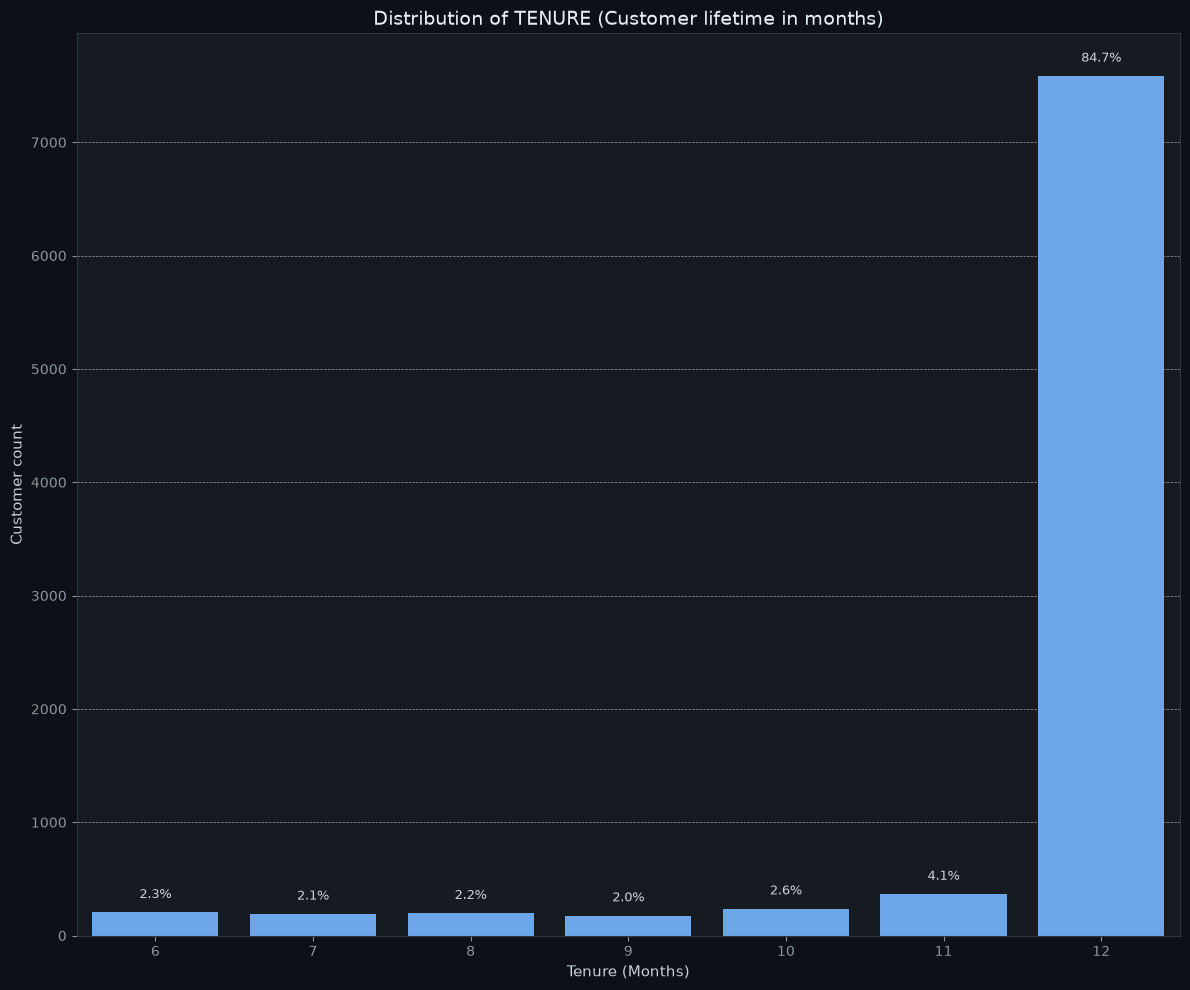

In [46]:
plt.figure(figsize=(12, 10))
ax = sns.countplot(
    data=df,
    x="TENURE",
)

plt.title("Distribution of TENURE (Customer lifetime in months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer count")
plt.tight_layout()

total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%\n"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(
        percentage,
        (x, y),
        ha="center",
        va="center",
        size=9
    )
plt.show()

### ***EDA Summary***

---

### ***General***
#### - Dataframe has **8950 rows** and **18 columns**.
#### - Dataframe size is **861 KB**.
#### - Dataframe columns:
##### `CUST_ID`, `BALANCE`, `BALANCE_FREQUENCY`, `PURCHASES`, `ONEOFF_PURCHASE`,
##### `INSTALLMENTS_PURCHASES`, `CASH_ADVANCE`, `PURCHASES_FREQUENCY`, `ONEOFF_PURCHASES_FREQUENCY`,
##### `PURCHASES_INSTALLMENTS_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`, `CASH_ADVANCE_TRX`, `PURCHASES_TRX`,
##### `CREDIT_LIMIT`, `PAYMENTS`, `MINIMUM_PAYMENTS`, `PRC_FULL_PAYMENT`, `TENURE`.
#### - Dataframe contains **17 numerical** and only **1 categorial** column.
#### - Dataframe `CUST_ID` no use feature (exact same unique count as df rows).

---

### ***CLEANING***
#### - Dataframe has **314 missing values** in general (`CREDIT_LIMIT` 313; `MINIMUM_PAYMENTS` 1)
#### which will be filled with **medians** in *FE*.
#### - Dataframe doesn't have duplicated values.
#### - Dataframe has a lot of outliers, but they will be transformed by log

---

### ***CORRELATIONS***
#### - `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES` and their frequencies
#### `PURCHASES_FREQUENCY`, `PURCHASES_TRX` make **multicollinearity**.
#### - `CASH_ADVANCE`, `PURCHASES` are 2 different opposite features.
#### - `BALANCE`, `CASH_ADVANCE`, `MINIMUM_PAYMENTS` have **inverse relationship**.
#### - `TENURE` and `CREDIT_LIMIT` are the **only independent features** (0.139 corr).